In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\gislab\AppData\Local\Temp\ipykernel_32356\116345580.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  filtered_multiple["area"] = filtered_multiple.geometry.area


             GEOID   Hsn__    H___P   Prcn_    Pr__P  Pr_____  P______  \
3929  080810006001  0.1592  13.4332  0.1855  90.4479   0.4051  98.3158   
4029  080099646002  0.1551  12.3346  0.2155  95.2734   0.0754  58.0451   
2566  080619601001  0.4182  77.2035  0.0964  41.5986   0.1441  78.9774   
3717  081219241002  0.2257  29.2634  0.1243  61.9896   0.1193  73.2331   
2733  080459521001  0.2899  47.1161  0.1479  77.1591   0.0720  56.1504   
...            ...     ...      ...     ...      ...      ...      ...   
1140  080710004002  0.1308   8.2647  0.2566  98.2678   0.0072   4.4211   
3378  080899682002  0.1084   5.2684  0.1701  85.5481   0.0312  30.5564   
2595  080459520011  0.1989  22.6467  0.0785  25.8352   0.2493  91.9398   
626   080279701023  0.2782  43.6954  0.1516  78.6934   0.0515  45.2632   
3439  080970004021  0.4082  75.6554  0.0828  29.0770   0.0422  38.6466   

      Prcnt_ln_  Prcnt_ln__  Prcnt_lw_  ...  D_I_C  \
3929     0.0000      0.0000     0.6814  ...      3   
402

C:\Users\gislab\AppData\Local\Temp\ipykernel_32356\116345580.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


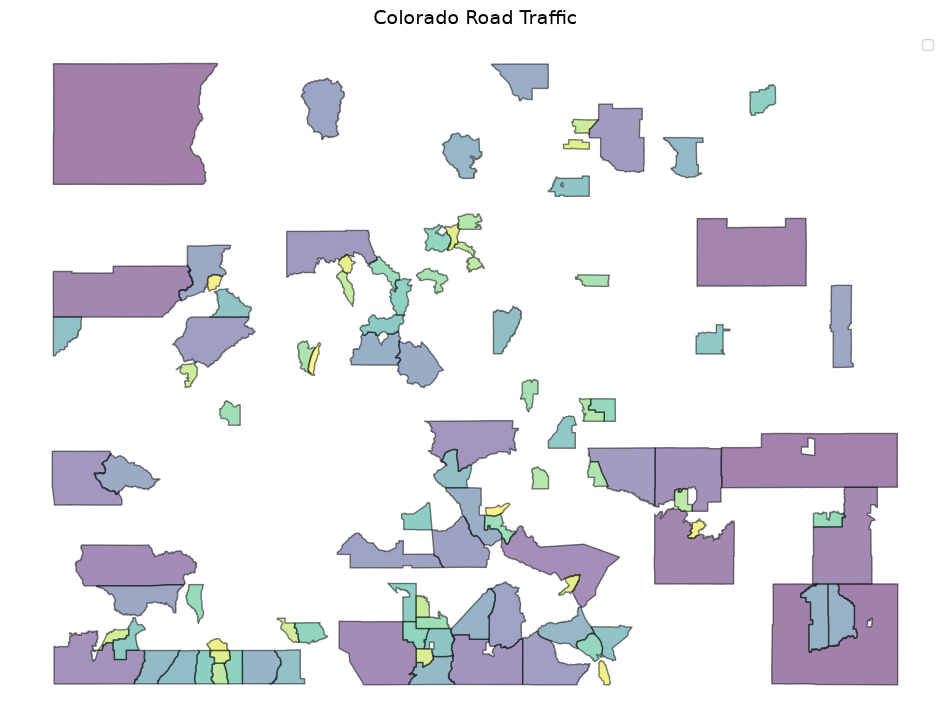

In [49]:
disport_cois = gpd.read_file("data/EJP_Main_English_v1_BlockGroup_20230803_-7417487947986533410/PublicFinal_CBG_112024.shp")


filtered_multiple = disport_cois[(disport_cois['POCFlag'] > 0) | (disport_cois['LIFlag'] > 0) | (disport_cois['TJ'] > 0) | (disport_cois['LEPFlag'] > 0) | (disport_cois['HCBFlag'] > 0) | (disport_cois['ESFlag'] > 0)]
#(disport_cois['Justice40F'] > 0)
#print(filtered_multiple)


filtered_multiple["geometry"] = filtered_multiple["geometry"].buffer(0)

    # Calculate area (units depend on CRS: degrees² for EPSG:4326, meters² for projected CRS)
filtered_multiple["area"] = filtered_multiple.geometry.area

sorted_multiple = filtered_multiple.sort_values(by="area", ascending=False)

sorted_multiple = sorted_multiple.iloc[:-1695]


print(sorted_multiple)



fig, ax = plt.subplots(figsize=(12, 10))

sorted_multiple.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")

ax.set_title("Colorado Road Traffic", fontsize=14)
ax.legend()
ax.axis("off")
plt.show()




In [ ]:
sorted_multiple.to_file('Dispro_Impact_Comms.shp')

In [ ]:
'''
n_ss = pd.read_csv('csvs/colorado_neutral_test_weights_100000_v1.csv')
n_sh = pd.read_csv('csvs/colorado_neutral_sh_100000_v1.csv')
o_ss = pd.read_csv('csvs/colorado_optimized_tcp_test_weights_100000_v1.csv')
o_sh = pd.read_csv('csvs/colorado_sh_optimized_100k.csv')
u_ss = pd.read_csv('csvs/colorado_unoptimized_test_weights_100000_v1.csv')
u_sh = pd.read_csv('csvs/colorado_unoptimized_sh_100k.csv')
#combined = pd.concat([es,se,sr], ignore_index = True)
'''

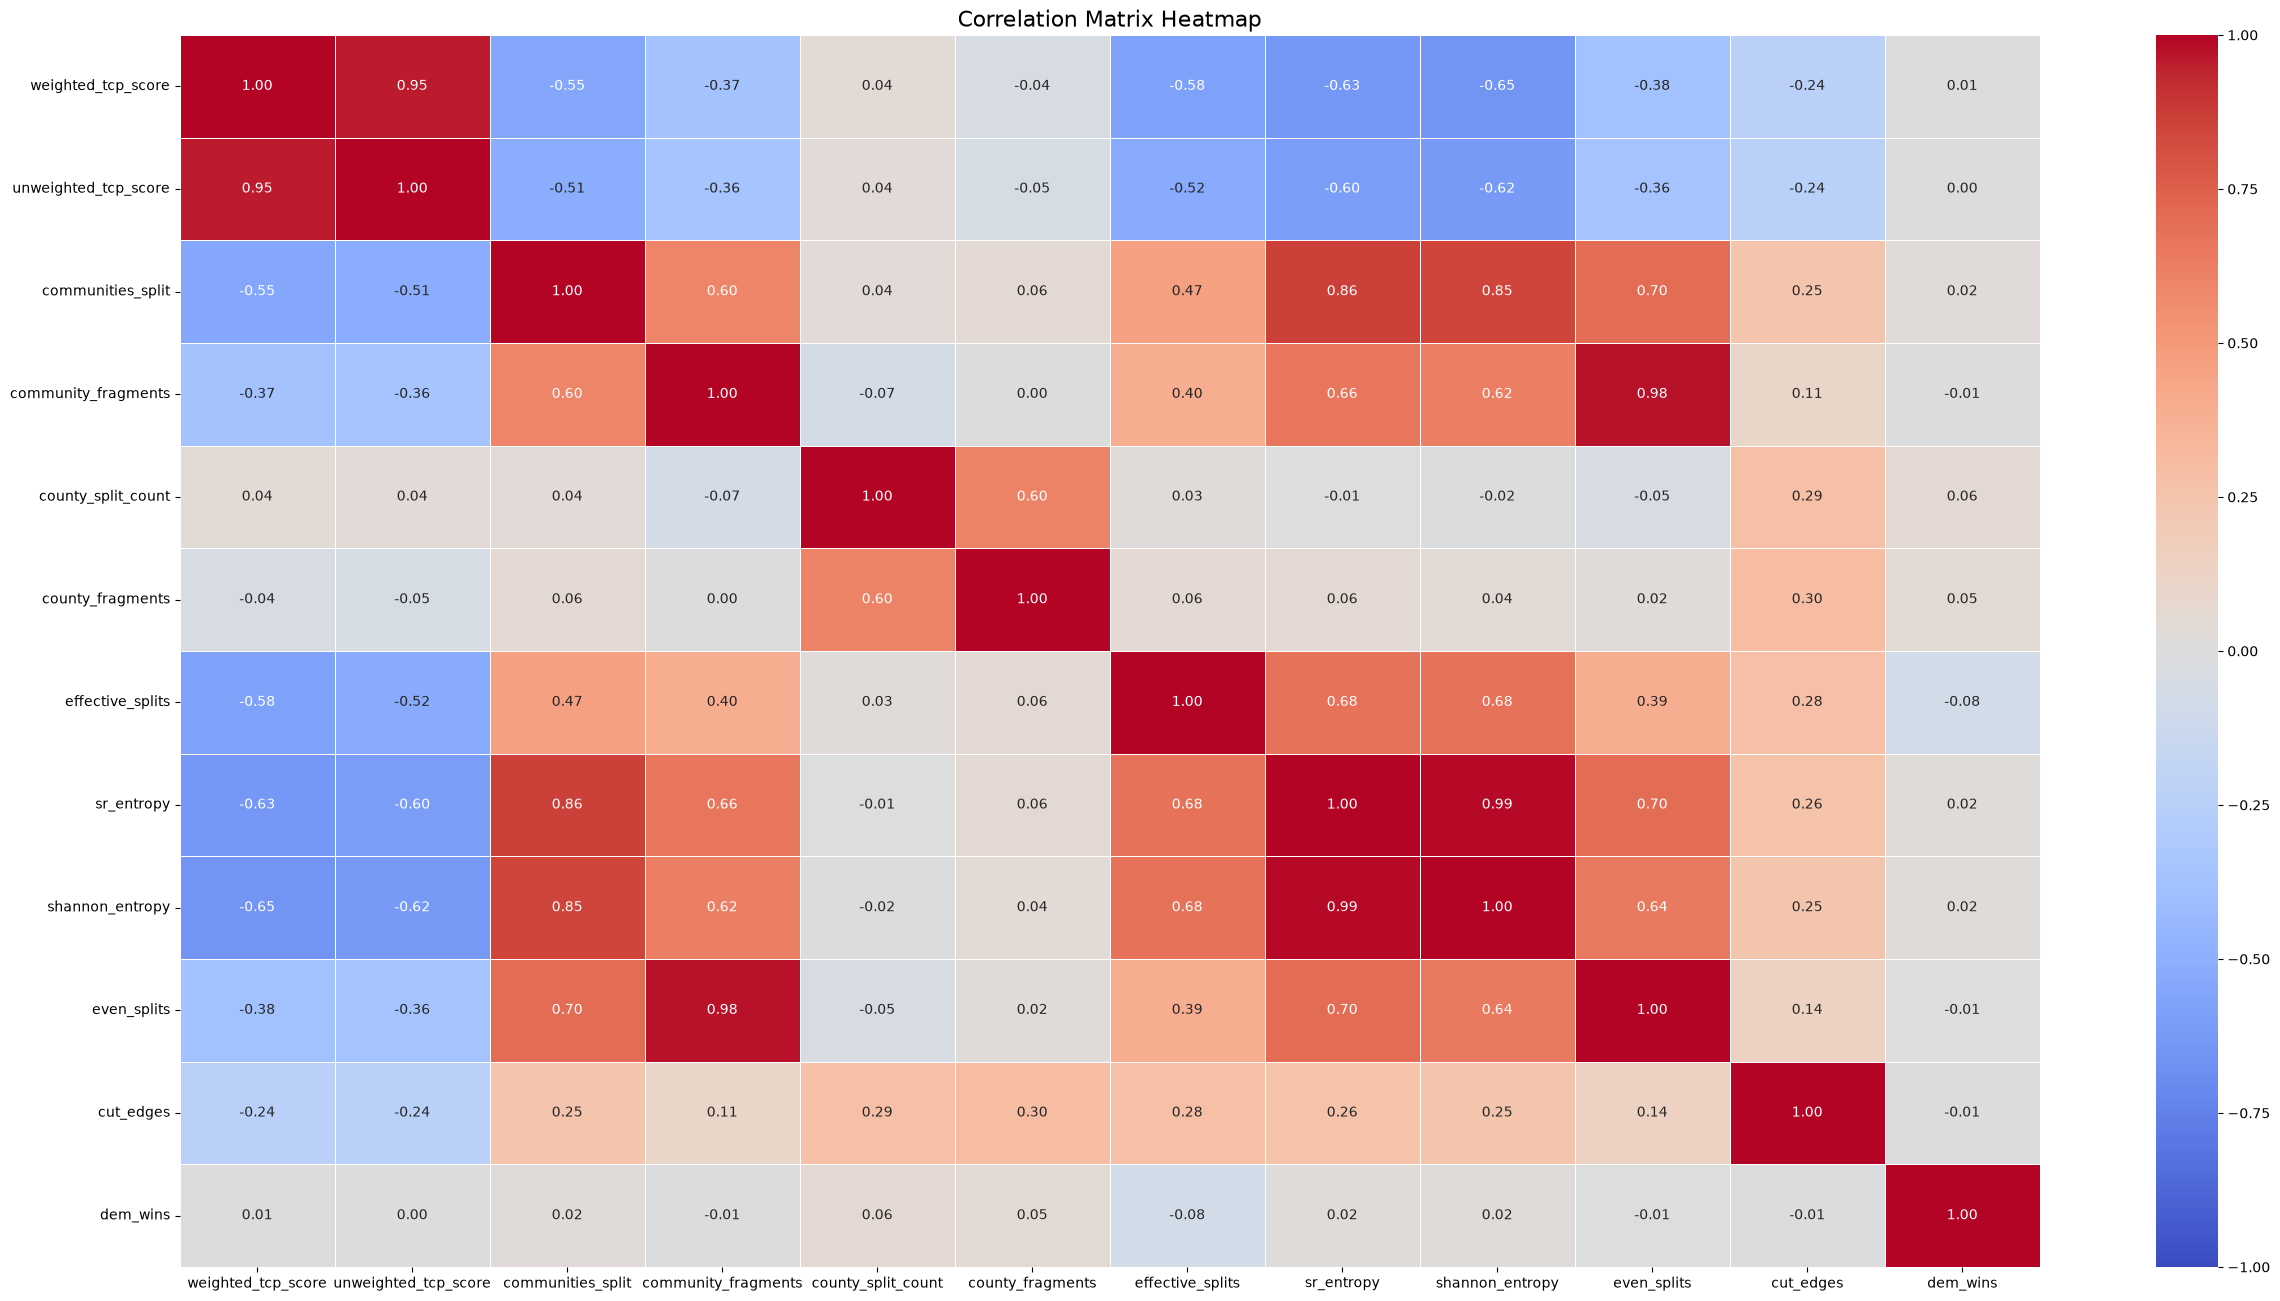

In [13]:
#print(n_ss.columns)
cols = ['weighted_tcp_score', 'unweighted_tcp_score', 'communities_split', 'community_fragments', 'county_split_count', 'county_fragments', 'effective_splits', 'sr_entropy', 'shannon_entropy', 'even_splits', 'cut_edges', 'dem_wins']
correlation_matrix = n_ss[cols].corr()
plt.figure(figsize=(30, 16))
sns.heatmap(
    correlation_matrix,
    annot=True,  # Shows the numerical correlation value in each cell
    cmap="coolwarm",  # Divergent color map (blue = negative, red = positive)
    fmt=".2f",  # Rounds numbers to 2 decimal places
    vmin=-1,  # Minimum anchor for the color bar
    vmax=1,  # Maximum anchor for the color bar
    linewidths=0.5,  # Adds a visible line boundary between cells
)

# 5. Display the plot
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.show()